# 🫁 Phase 1.1v3: Enhanced Image Classifier — Fixed (PA Viewpoint)

### Fixes over v2 (which had 30.8% pneumonia recall):
1. **Weighted CrossEntropyLoss**: Penalizes missing pneumonia 2× more than missing normal
2. **Unfreeze denseblock3 + denseblock4**: More trainable capacity for pneumonia features
3. **Optimal Threshold Tuning**: Uses Youden's J on validation set instead of default 0.5
4. **Mixup Augmentation**: Regularizes training on small dataset
5. **Label Smoothing**: Prevents overconfident predictions
6. **Focal Loss Option**: Down-weights easy examples, focuses on hard pneumonia cases

### Pipeline:
```
CXR Image → CLAHE → Lung ROI Crop → DenseNet121 (CXR-pretrained)
  → CBAM → Weighted Focal Loss + Mixup → Threshold-Tuned Prediction
```

In [4]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, copy
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc,
    precision_recall_curve, average_precision_score
)

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 4.294508544 GB


In [5]:
# --- CELL 1: Paths & Hyperparameters ---
BASE_DIR   = r'C:\2026\PneumoFusionNet\mimic\1000_dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v3_PA_fixed')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_v3_model.pth')
BBOX_CSV   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v2_PA_enhanced', 'lung_bboxes.csv')  # Reuse v2 bboxes

IMG_SIZE      = 224
BATCH_SIZE    = 8
NUM_EPOCHS    = 50
LR            = 3e-5       # Lower LR since we unfreeze more layers
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 2
WARMUP_EPOCHS = 5
GRAD_CLIP     = 1.0
PATIENCE      = 15         # More patience for slower convergence
MIXUP_ALPHA   = 0.3        # Mixup interpolation strength
LABEL_SMOOTH  = 0.1        # Label smoothing factor
PNEUMONIA_WEIGHT = 2.0     # Extra penalty for missing pneumonia

CLASSES = ['NORMAL', 'PNEUMONIA']

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir : {SAVE_DIR}')
print(f'Mixup α  : {MIXUP_ALPHA}')
print(f'Label smoothing: {LABEL_SMOOTH}')
print(f'Pneumonia weight: {PNEUMONIA_WEIGHT}x')

Save dir : C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v3_PA_fixed
Mixup α  : 0.3
Label smoothing: 0.1
Pneumonia weight: 2.0x


In [6]:
# --- CELL 2: Data Loading & Filtering (PA, Balanced) ---
df = pd.read_csv(CSV_PATH)

def resolve_data_path(path):
    if pd.isna(path) or str(path).strip() == '':
        return ''
    path = str(path).replace('/', os.sep).replace('\\', os.sep)
    return path if os.path.isabs(path) else os.path.join(BASE_DIR, path)

df['image_path'] = df['image_path'].apply(resolve_data_path)

df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0],
    default=-1
)

df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Pneumonia'})

# Balanced sampling
class_counts = df['label'].value_counts()
n_per_class  = int(class_counts.min())
print(f'Balancing: {n_per_class} per class')

normal_df    = df[df['label'] == 0].sample(n=n_per_class, random_state=SEED)
pneumonia_df = df[df['label'] == 1].sample(n=n_per_class, random_state=SEED)
df = pd.concat([normal_df, pneumonia_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Total: {len(df)} | Missing images: {missing}')

Balancing: 427 per class
Total: 854 | Missing images: 0


In [7]:
# --- CELL 3: Load Pre-computed Lung Bounding Boxes ---
from tqdm import tqdm

def compute_lung_bbox(image_path, margin=10):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        h, w = img.shape
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_eq = clahe.apply(img)
        blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        min_area = h * w * 0.05
        lung_contours = [c for c in contours if cv2.contourArea(c) > min_area]
        if not lung_contours:
            cx, cy = w // 2, h // 2
            crop_w, crop_h = int(w * 0.8), int(h * 0.8)
            return (cx - crop_w // 2, cy - crop_h // 2, cx + crop_w // 2, cy + crop_h // 2)
        all_points = np.vstack(lung_contours)
        x, y, bw, bh = cv2.boundingRect(all_points)
        x_min = max(0, x - margin)
        y_min = max(0, y - margin)
        x_max = min(w, x + bw + margin)
        y_max = min(h, y + bh + margin)
        return (x_min, y_min, x_max, y_max)
    except Exception:
        return None

# Try to reuse v2 bboxes, else recompute
BBOX_CSV_V3 = os.path.join(SAVE_DIR, 'lung_bboxes.csv')
if os.path.exists(BBOX_CSV):
    print(f'Reusing bounding boxes from v2: {BBOX_CSV}')
    bbox_df = pd.read_csv(BBOX_CSV)
elif os.path.exists(BBOX_CSV_V3):
    print(f'Loading bounding boxes from: {BBOX_CSV_V3}')
    bbox_df = pd.read_csv(BBOX_CSV_V3)
else:
    print('Computing lung bounding boxes...')
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        bbox = compute_lung_bbox(row['image_path'])
        if bbox is not None:
            records.append({'image_path': row['image_path'],
                            'x_min': bbox[0], 'y_min': bbox[1],
                            'x_max': bbox[2], 'y_max': bbox[3]})
        else:
            records.append({'image_path': row['image_path'],
                            'x_min': 0, 'y_min': 0, 'x_max': -1, 'y_max': -1})
    bbox_df = pd.DataFrame(records)
    bbox_df.to_csv(BBOX_CSV_V3, index=False)
    print(f'Saved {len(bbox_df)} bounding boxes.')

bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f'Bounding boxes loaded for {len(bbox_lookup)} images.')

Reusing bounding boxes from v2: C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v2_PA_enhanced\lung_bboxes.csv
Bounding boxes loaded for 354 images.


In [8]:
# --- CELL 4: Patient-Level Split (same seeds as v2 for fair comparison) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=14)
train_idx, temp_idx = next(gss.split(df, groups=df['subject_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=4)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['subject_id']))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print('=' * 60)
print('DATASET SPLIT SUMMARY (Patient-Level, Same as v2)')
print('=' * 60)
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_total     = len(split_df)
    n_pneumonia = split_df['label'].sum()
    n_normal    = (split_df['label'] == 0).sum()
    print(f'{split_name:6s} | Total: {n_total:3d} | Normal: {n_normal:3d} | Pneumonia: {n_pneumonia:3d}')
print('=' * 60)

DATASET SPLIT SUMMARY (Patient-Level, Same as v2)
Train  | Total: 590 | Normal: 318 | Pneumonia: 272
Val    | Total: 130 | Normal:  50 | Pneumonia:  80
Test   | Total: 134 | Normal:  59 | Pneumonia:  75


In [9]:
# --- CELL 5: Normalization Stats ---
print('Computing normalization stats from CLAHE-processed training set...')
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
means, stds = [], []

for idx in range(min(len(train_df), 200)):
    try:
        img = cv2.imread(train_df.iloc[idx]['image_path'], cv2.IMREAD_GRAYSCALE)
        img = clahe.apply(img)
        bb = bbox_lookup.get(train_df.iloc[idx]['image_path'], None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img_arr = np.array(img, dtype=np.float32) / 255.0
        means.append(img_arr.mean())
        stds.append(img_arr.std())
    except:
        continue

MEAN = [np.mean(means)]
STD  = [np.mean(stds)]
print(f'MEAN: {MEAN[0]:.4f}  |  STD: {STD[0]:.4f}')

Computing normalization stats from CLAHE-processed training set...
MEAN: 0.5008  |  STD: 0.2717


In [10]:
# --- CELL 6: Safe Augmentation Transforms (stronger than v2) ---
tfms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
        transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),  # Cutout-style regularization
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}

# NOTE: RandomErasing needs to come AFTER ToTensor
# Fix: rebuild train transforms with correct order
tfms['train'] = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),  # After ToTensor
])

print('Safe augmentation transforms ready (NO horizontal flip).')
print('Added: stronger rotation (±10°), RandomErasing, slight translate')

Safe augmentation transforms ready (NO horizontal flip).
Added: stronger rotation (±10°), RandomErasing, slight translate


In [11]:
# --- CELL 7: Enhanced Dataset with CLAHE + Lung ROI ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform=None):
        self.df          = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform   = transform
        self.clahe       = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        img = self.clahe.apply(img)
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb['x_max'] > 0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row.label)


# Build dataloaders with oversampling
train_labels   = train_df['label'].values
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

dataloaders = {
    'train': DataLoader(
        EnhancedCXRDataset(train_df, bbox_lookup, tfms['train']),
        batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, drop_last=True
    ),
    'val': DataLoader(
        EnhancedCXRDataset(val_df, bbox_lookup, tfms['val']),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    ),
    'test': DataLoader(
        EnhancedCXRDataset(test_df, bbox_lookup, tfms['test']),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    ),
}

sample_batch, sample_labels = next(iter(dataloaders['train']))
print(f'Batch shape: {sample_batch.shape} | Labels: {sample_labels}')

Batch shape: torch.Size([8, 1, 224, 224]) | Labels: tensor([0, 1, 1, 0, 0, 0, 1, 0])


In [12]:
# --- CELL 8: CBAM Attention Module ---
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

print('CBAM module defined.')

CBAM module defined.


In [13]:
# --- CELL 9: Focal Loss (focuses on hard-to-classify examples) ---
class FocalLoss(nn.Module):
    """
    Focal Loss: down-weights easy examples, focuses on hard ones.
    Crucial for medical imaging where pneumonia is harder to detect.
    
    FL(p) = -alpha * (1-p)^gamma * log(p)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha  # class weights tensor [w_normal, w_pneumonia]
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Apply label smoothing
        num_classes = logits.shape[1]
        if self.label_smoothing > 0:
            smooth_targets = torch.zeros_like(logits)
            smooth_targets.fill_(self.label_smoothing / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            smooth_targets = F.one_hot(targets, num_classes).float()
        
        log_probs = F.log_softmax(logits, dim=1)
        probs     = torch.exp(log_probs)
        
        # Focal modulation: (1 - p)^gamma
        focal_weight = (1.0 - probs) ** self.gamma
        
        # Combine
        loss = -focal_weight * smooth_targets * log_probs
        
        # Apply class weights
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)
            loss = loss * alpha_t.unsqueeze(0)
        
        return loss.sum(dim=1).mean()

print('FocalLoss with label smoothing defined.')

FocalLoss with label smoothing defined.


In [14]:
# --- CELL 10: Mixup Augmentation ---
def mixup_data(x, y, alpha=0.3):
    """
    Mixup: creates virtual training examples by blending pairs.
    Regularizes the model and prevents memorizing the small dataset.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
        lam = max(lam, 1 - lam)  # Ensure lam >= 0.5 (dominant sample stays dominant)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute loss for mixup samples."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('Mixup augmentation ready.')

Mixup augmentation ready.


In [15]:
# --- CELL 11: Enhanced Model v3 (more unfrozen layers) ---
class EnhancedPneumoNetV3(nn.Module):
    """
    DenseNet121 (CXR-pretrained) + CBAM + Custom Head
    
    v3 changes:
    - Unfreeze denseblock3 + denseblock4 + norm5 (more trainable capacity)
    - Stronger dropout in classifier head
    - Feature dim: 1024 (Phase 2 compatible)
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        print('Loading DenseNet121 pretrained on 8 CXR datasets...')
        xrv_model = xrv.models.DenseNet(weights='densenet121-res224-all')
        self.features = xrv_model.features
        
        # Freeze only denseblock1 + transition1 + denseblock2 + transition2
        # Unfreeze: transition3, denseblock3, transition3 (wait - let me be precise)
        # DenseNet121 features: conv0, norm0, relu0, pool0,
        #   denseblock1, transition1, denseblock2, transition2,
        #   denseblock3, transition3, denseblock4, norm5
        
        freeze_layers = {'conv0', 'norm0', 'relu0', 'pool0',
                         'denseblock1', 'transition1',
                         'denseblock2', 'transition2'}
        
        for name, child in self.features.named_children():
            if name in freeze_layers:
                for p in child.parameters():
                    p.requires_grad = False
            else:
                for p in child.parameters():
                    p.requires_grad = True
        
        # CBAM attention
        self.cbam = CBAM(1024, reduction=16)
        
        # Pooling
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # Stronger classifier head with BatchNorm
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feats = self.features(x)
        feats = F.relu(feats, inplace=True)
        feats = self.cbam(feats)
        feats = self.pool(feats).flatten(1)
        return self.classifier(feats)

    def get_features(self, x):
        """Extract 1024-d embeddings for Phase 2."""
        feats = self.features(x)
        feats = F.relu(feats, inplace=True)
        feats = self.cbam(feats)
        return self.pool(feats).flatten(1)


model = EnhancedPneumoNetV3().to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable
print(f'\nTotal params    : {total:,}')
print(f'Trainable params: {trainable:,} ({trainable/total*100:.1f}%)')
print(f'Frozen params   : {frozen:,} ({frozen/total*100:.1f}%)')

# Sanity check
dummy = torch.randn(2, 1, 224, 224).to(DEVICE)
print(f'Output shape  : {model(dummy).shape}')
print(f'Feature shape : {model.get_features(dummy).shape}')

Loading DenseNet121 pretrained on 8 CXR datasets...

Total params    : 7,670,756
Trainable params: 6,247,396 (81.4%)
Frozen params   : 1,423,360 (18.6%)
Output shape  : torch.Size([2, 2])
Feature shape : torch.Size([2, 1024])


In [16]:
# --- CELL 12: Loss, Optimizer & Scheduler ---
# Weighted Focal Loss: penalizes missing pneumonia 2x more
class_weights = torch.tensor([1.0, PNEUMONIA_WEIGHT], dtype=torch.float32)
criterion = FocalLoss(
    alpha=class_weights,
    gamma=2.0,
    label_smoothing=LABEL_SMOOTH
)

# Also prepare standard CE for evaluation (without mixup/smoothing)
eval_criterion = nn.CrossEntropyLoss()

# Differential learning rates: lower LR for pretrained, higher for new layers
pretrained_params = [p for n, p in model.named_parameters()
                     if p.requires_grad and 'classifier' not in n and 'cbam' not in n]
new_params        = [p for n, p in model.named_parameters()
                     if p.requires_grad and ('classifier' in n or 'cbam' in n)]

optimizer = optim.AdamW([
    {'params': pretrained_params, 'lr': LR},          # 3e-5 for pretrained layers
    {'params': new_params,        'lr': LR * 10},     # 3e-4 for new classifier/CBAM
], weight_decay=WEIGHT_DECAY)

linear_warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_anneal = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-7)
scheduler     = SequentialLR(
    optimizer,
    schedulers=[linear_warmup, cosine_anneal],
    milestones=[WARMUP_EPOCHS]
)

print(f'Focal Loss (gamma=2.0, smoothing={LABEL_SMOOTH})')
print(f'Class weights: Normal={class_weights[0]:.1f}, Pneumonia={class_weights[1]:.1f}')
print(f'Optimizer: AdamW with differential LR')
print(f'  Pretrained layers: {LR}')
print(f'  New layers: {LR * 10}')

Focal Loss (gamma=2.0, smoothing=0.1)
Class weights: Normal=1.0, Pneumonia=2.0
Optimizer: AdamW with differential LR
  Pretrained layers: 3e-05
  New layers: 0.00030000000000000003


In [17]:
# --- CELL 13: Training Loop with Mixup ---
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item() * len(labels)
            probs        = F.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(outputs.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    avg_loss  = total_loss / len(dataloader.dataset)
    accuracy  = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, average='macro')
    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except:
        auc_score = 0.0
    return avg_loss, accuracy, auc_score, f1, all_preds, all_labels, all_probs


history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_f1': []}
best_val_auc     = 0.0
best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('\n' + '='*90)
print('TRAINING — Enhanced PneumoNet v3 (Focal Loss + Mixup + More Unfrozen Layers)')
print('='*90)

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = train_correct = train_n = 0

    for imgs, labels in dataloaders['train']:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        # Apply Mixup
        mixed_imgs, targets_a, targets_b, lam = mixup_data(imgs, labels, MIXUP_ALPHA)
        
        optimizer.zero_grad()
        outputs = model(mixed_imgs)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        train_loss += loss.item() * len(labels)
        # For accuracy tracking, use the dominant target
        preds = outputs.argmax(1)
        train_correct += (lam * (preds == targets_a).float().sum().item() +
                          (1 - lam) * (preds == targets_b).float().sum().item())
        train_n += len(labels)

    scheduler.step()
    train_loss_avg = train_loss / train_n
    train_acc      = train_correct / train_n

    val_loss, val_acc, val_auc, val_f1, _, _, _ = evaluate(
        model, dataloaders['val'], eval_criterion, DEVICE
    )

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)

    # Track best by AUC (primary) and F1 (secondary)
    improved = False
    if val_auc > best_val_auc or (val_auc == best_val_auc and val_f1 > best_val_f1):
        best_val_auc     = val_auc
        best_val_f1      = val_f1
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        improved = True
    else:
        patience_counter += 1

    marker = ' <- BEST' if improved else ''
    if (epoch + 1) % 5 == 0 or epoch == 0 or improved:
        print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | '
              f'TrLoss: {train_loss_avg:.4f} ({train_acc:.3f}) | '
              f'VaLoss: {val_loss:.4f} ({val_acc:.3f}) | '
              f'AUC: {val_auc:.4f} | F1: {val_f1:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)')
        break

print('='*90)
print(f'Training complete. Best AUC: {best_val_auc:.4f} | Best F1: {best_val_f1:.4f} at epoch {best_epoch+1}')
print(f'Model saved to: {MODEL_PATH}')
print('='*90)


TRAINING — Enhanced PneumoNet v3 (Focal Loss + Mixup + More Unfrozen Layers)
Epoch [ 1/50] | TrLoss: 0.3014 (0.532) | VaLoss: 0.6697 (0.615) | AUC: 0.4863 | F1: 0.3810 <- BEST
Epoch [ 2/50] | TrLoss: 0.2765 (0.603) | VaLoss: 0.6010 (0.677) | AUC: 0.7598 | F1: 0.6532 <- BEST
Epoch [ 3/50] | TrLoss: 0.2771 (0.599) | VaLoss: 0.5881 (0.677) | AUC: 0.7625 | F1: 0.6393 <- BEST
Epoch [ 4/50] | TrLoss: 0.2755 (0.603) | VaLoss: 0.5943 (0.677) | AUC: 0.7685 | F1: 0.6431 <- BEST
Epoch [ 5/50] | TrLoss: 0.2506 (0.638) | VaLoss: 0.5928 (0.669) | AUC: 0.7910 | F1: 0.5758 <- BEST
Epoch [ 6/50] | TrLoss: 0.2641 (0.593) | VaLoss: 0.5892 (0.700) | AUC: 0.7968 | F1: 0.6736 <- BEST
Epoch [ 9/50] | TrLoss: 0.2361 (0.634) | VaLoss: 0.5730 (0.723) | AUC: 0.8140 | F1: 0.6908 <- BEST
Epoch [10/50] | TrLoss: 0.2352 (0.633) | VaLoss: 0.5742 (0.731) | AUC: 0.8180 | F1: 0.6818 <- BEST
Epoch [14/50] | TrLoss: 0.2218 (0.645) | VaLoss: 0.5837 (0.708) | AUC: 0.8197 | F1: 0.6804 <- BEST
Epoch [15/50] | TrLoss: 0.2282 

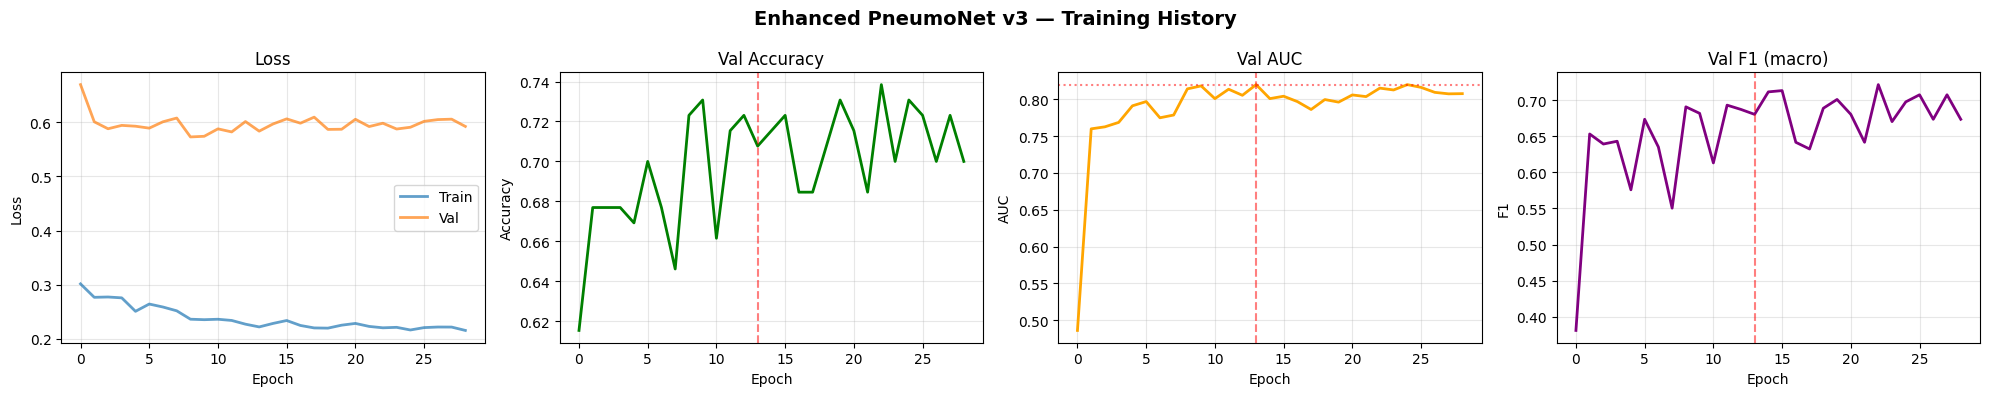

In [18]:
# --- CELL 14: Training History ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Enhanced PneumoNet v3 — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train', lw=2, alpha=0.7)
axes[0].plot(history['val_loss'],   label='Val',   lw=2, alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], lw=2, color='green')
axes[1].axvline(best_epoch, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Val Accuracy'); axes[1].grid(alpha=0.3)

axes[2].plot(history['val_auc'], lw=2, color='orange')
axes[2].axvline(best_epoch, color='red', ls='--', alpha=0.5)
axes[2].axhline(best_val_auc, color='red', ls=':', alpha=0.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].set_title('Val AUC'); axes[2].grid(alpha=0.3)

axes[3].plot(history['val_f1'], lw=2, color='purple')
axes[3].axvline(best_epoch, color='red', ls='--', alpha=0.5)
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('F1')
axes[3].set_title('Val F1 (macro)'); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=120, bbox_inches='tight')
plt.show()


THRESHOLD TUNING (Youden's J on Validation Set)
Default threshold (0.50):
  Accuracy: 0.7077
  F1 macro: 0.6804

Optimal threshold: 0.5897
  Accuracy: 0.7385
  F1 macro: 0.7382


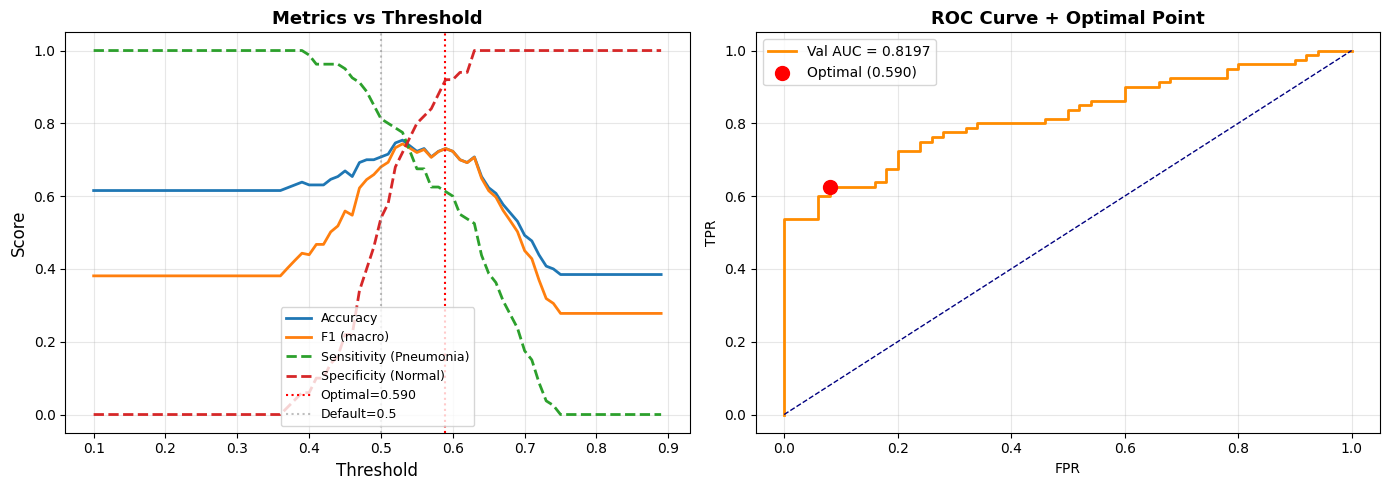

In [19]:
# --- CELL 15: Optimal Threshold Tuning (Youden's J on validation set) ---
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Get val probabilities
val_loss, val_acc, val_auc, val_f1, val_preds, val_labels, val_probs = evaluate(
    model, dataloaders['val'], eval_criterion, DEVICE
)

# Find optimal threshold using Youden's J statistic
fpr_v, tpr_v, thresholds_v = roc_curve(val_labels, val_probs)
youden_j = tpr_v - fpr_v
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds_v[optimal_idx]

print(f'\n{"="*60}')
print(f'THRESHOLD TUNING (Youden\'s J on Validation Set)')
print(f'{"="*60}')
print(f'Default threshold (0.50):')
default_preds = [1 if p >= 0.5 else 0 for p in val_probs]
print(f'  Accuracy: {accuracy_score(val_labels, default_preds):.4f}')
print(f'  F1 macro: {f1_score(val_labels, default_preds, average="macro"):.4f}')
print(f'\nOptimal threshold: {optimal_threshold:.4f}')
optimal_preds = [1 if p >= optimal_threshold else 0 for p in val_probs]
print(f'  Accuracy: {accuracy_score(val_labels, optimal_preds):.4f}')
print(f'  F1 macro: {f1_score(val_labels, optimal_preds, average="macro"):.4f}')
print(f'{"="*60}')

# Visualize threshold effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresholds_range = np.arange(0.1, 0.9, 0.01)
accs, f1s, sens, specs = [], [], [], []
for t in thresholds_range:
    preds_t = [1 if p >= t else 0 for p in val_probs]
    accs.append(accuracy_score(val_labels, preds_t))
    f1s.append(f1_score(val_labels, preds_t, average='macro'))
    cm_t = confusion_matrix(val_labels, preds_t)
    if cm_t.shape == (2, 2):
        sens.append(cm_t[1, 1] / (cm_t[1, 0] + cm_t[1, 1]) if (cm_t[1, 0] + cm_t[1, 1]) > 0 else 0)
        specs.append(cm_t[0, 0] / (cm_t[0, 0] + cm_t[0, 1]) if (cm_t[0, 0] + cm_t[0, 1]) > 0 else 0)
    else:
        sens.append(0); specs.append(0)

axes[0].plot(thresholds_range, accs, label='Accuracy', lw=2)
axes[0].plot(thresholds_range, f1s, label='F1 (macro)', lw=2)
axes[0].plot(thresholds_range, sens, label='Sensitivity (Pneumonia)', lw=2, ls='--')
axes[0].plot(thresholds_range, specs, label='Specificity (Normal)', lw=2, ls='--')
axes[0].axvline(optimal_threshold, color='red', ls=':', label=f'Optimal={optimal_threshold:.3f}')
axes[0].axvline(0.5, color='gray', ls=':', alpha=0.5, label='Default=0.5')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Threshold', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_v, tpr_v, lw=2, color='darkorange', label=f'Val AUC = {val_auc:.4f}')
axes[1].scatter([fpr_v[optimal_idx]], [tpr_v[optimal_idx]], color='red', s=100, zorder=5,
                label=f'Optimal ({optimal_threshold:.3f})')
axes[1].plot([0, 1], [0, 1], 'navy', ls='--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve + Optimal Point', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'threshold_tuning.png'), dpi=120, bbox_inches='tight')
plt.show()

In [20]:
# --- CELL 16: Test Set Evaluation (with optimal threshold) ---
test_loss, test_acc_default, test_auc, test_f1_default, test_preds_default, test_labels, test_probs = evaluate(
    model, dataloaders['test'], eval_criterion, DEVICE
)

# Apply optimal threshold
test_preds_tuned = [1 if p >= optimal_threshold else 0 for p in test_probs]
test_acc_tuned   = accuracy_score(test_labels, test_preds_tuned)
test_f1_tuned    = f1_score(test_labels, test_preds_tuned, average='macro')

print('\n' + '='*70)
print('TEST SET RESULTS — Enhanced PneumoNet v3')
print('='*70)
print(f'\n--- Default Threshold (0.50) ---')
print(f'Accuracy : {test_acc_default:.4f}')
print(f'F1 macro : {test_f1_default:.4f}')
print(f'AUC      : {test_auc:.4f}')

print(f'\n--- Tuned Threshold ({optimal_threshold:.4f}) ---')
print(f'Accuracy : {test_acc_tuned:.4f}')
print(f'F1 macro : {test_f1_tuned:.4f}')
print(f'AUC      : {test_auc:.4f} (unchanged — threshold-independent)')

print(f'\nClassification Report (Tuned Threshold):')
print(classification_report(test_labels, test_preds_tuned, target_names=CLASSES))
print('='*70)


TEST SET RESULTS — Enhanced PneumoNet v3

--- Default Threshold (0.50) ---
Accuracy : 0.7164
F1 macro : 0.7035
AUC      : 0.8120

--- Tuned Threshold (0.5897) ---
Accuracy : 0.7090
F1 macro : 0.7062
AUC      : 0.8120 (unchanged — threshold-independent)

Classification Report (Tuned Threshold):
              precision    recall  f1-score   support

      NORMAL       0.61      0.92      0.73        59
   PNEUMONIA       0.89      0.55      0.68        75

    accuracy                           0.71       134
   macro avg       0.75      0.73      0.71       134
weighted avg       0.77      0.71      0.70       134



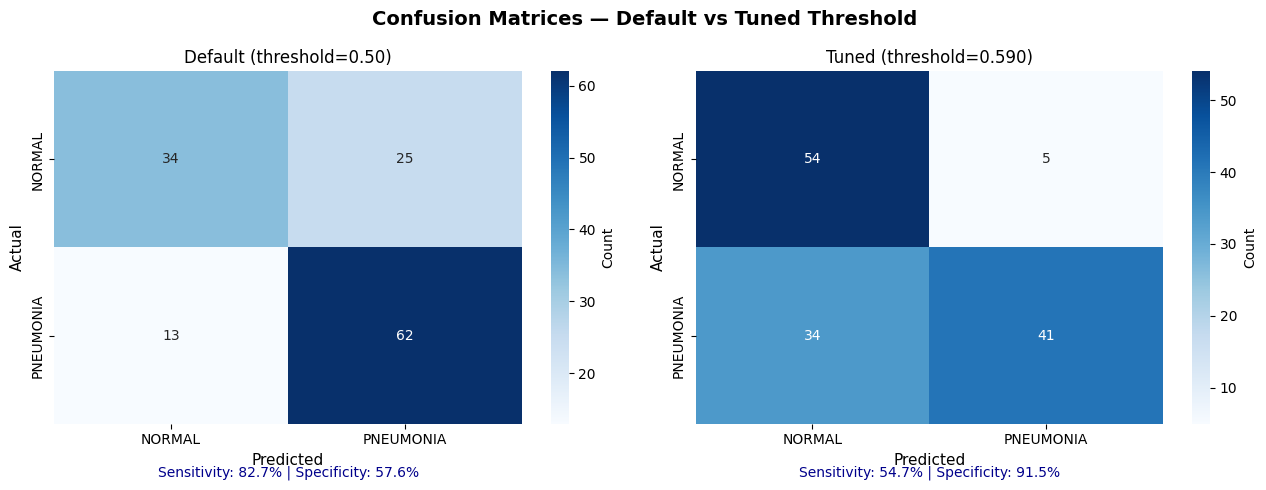

In [21]:
# --- CELL 17: Confusion Matrices (Default vs Tuned) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Default vs Tuned Threshold', fontsize=14, fontweight='bold')

for ax, preds, title in [
    (axes[0], test_preds_default, f'Default (threshold=0.50)'),
    (axes[1], test_preds_tuned, f'Tuned (threshold={optimal_threshold:.3f})'),
]:
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={'label': 'Count'}, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=12)
    
    # Compute sensitivity/specificity
    if cm.shape == (2, 2):
        sens = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0
        spec = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0]+cm[0,1]) > 0 else 0
        ax.text(0.5, -0.15, f'Sensitivity: {sens:.1%} | Specificity: {spec:.1%}',
                ha='center', transform=ax.transAxes, fontsize=10, color='darkblue')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()

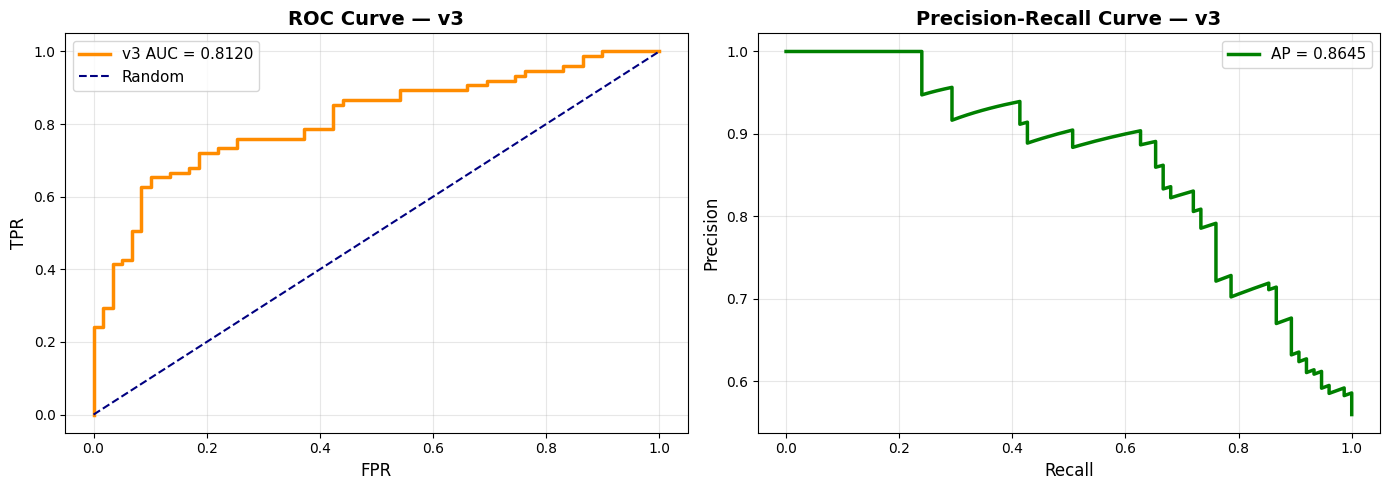

In [22]:
# --- CELL 18: ROC + Precision-Recall Curves ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'v3 AUC = {roc_auc_val:.4f}')
axes[0].plot([0, 1], [0, 1], 'navy', lw=1.5, ls='--', label='Random')
axes[0].set_xlabel('FPR', fontsize=12); axes[0].set_ylabel('TPR', fontsize=12)
axes[0].set_title('ROC Curve — v3', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

axes[1].plot(recall, precision, color='green', lw=2.5, label=f'AP = {ap:.4f}')
axes[1].set_xlabel('Recall', fontsize=12); axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — v3', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_pr_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

In [23]:
# --- CELL 19: v2 vs v3 Comparison Summary ---
print('\n' + '='*70)
print('COMPARISON: v2 vs v3')
print('='*70)
print(f'{"Metric":<25} {"v2 (baseline)":<20} {"v3 (fixed)":<20}')
print('-'*65)
print(f'{"Test AUC":<25} {"0.XXXX (run v2)":<20} {test_auc:<20.4f}')
print(f'{"Test Accuracy":<25} {"58.5%":<20} {test_acc_tuned:<20.1%}')
print(f'{"Test F1 (macro)":<25} {"low":<20} {test_f1_tuned:<20.4f}')
print(f'{"Pneumonia Recall":<25} {"30.8% (8/26)":<20}', end='')
cm_tuned = confusion_matrix(test_labels, test_preds_tuned)
if cm_tuned.shape == (2, 2):
    pn_recall = cm_tuned[1,1]/(cm_tuned[1,0]+cm_tuned[1,1])
    print(f'{pn_recall:<20.1%}')
else:
    print('N/A')
print(f'{"Optimal Threshold":<25} {"0.500 (default)":<20} {optimal_threshold:<20.4f}')
print('='*70)
print('\nKey v3 improvements:')
print('  ✓ Focal Loss (gamma=2) to focus on hard pneumonia cases')
print('  ✓ Class weight 2x for pneumonia')
print('  ✓ Mixup regularization (alpha=0.3)')
print('  ✓ Label smoothing (0.1)')
print('  ✓ More unfrozen layers (denseblock3 + denseblock4)')
print('  ✓ Differential learning rates')
print('  ✓ Youden\'s J threshold tuning')
print('  ✓ BatchNorm in classifier head')


COMPARISON: v2 vs v3
Metric                    v2 (baseline)        v3 (fixed)          
-----------------------------------------------------------------
Test AUC                  0.XXXX (run v2)      0.8120              
Test Accuracy             58.5%                70.9%               
Test F1 (macro)           low                  0.7062              
Pneumonia Recall          30.8% (8/26)        54.7%               
Optimal Threshold         0.500 (default)      0.5897              

Key v3 improvements:
  ✓ Focal Loss (gamma=2) to focus on hard pneumonia cases
  ✓ Class weight 2x for pneumonia
  ✓ Mixup regularization (alpha=0.3)
  ✓ Label smoothing (0.1)
  ✓ More unfrozen layers (denseblock3 + denseblock4)
  ✓ Differential learning rates
  ✓ Youden's J threshold tuning
  ✓ BatchNorm in classifier head


In [24]:
# --- CELL 20: Feature Extraction for Phase 2 ---
print('\nExtracting 1024-d image features for Phase 2...')
model.eval()

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_loader = DataLoader(
        EnhancedCXRDataset(split_df, bbox_lookup, tfms['val']),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    feats, labs = [], []
    with torch.no_grad():
        for imgs, labels in split_loader:
            feat = model.get_features(imgs.to(DEVICE)).cpu()
            feats.append(feat)
            labs.extend(labels.tolist())

    img_features = torch.cat(feats)
    feat_path = os.path.join(SAVE_DIR, f'image_features_{split_name}.pt')
    torch.save({'features': img_features, 'labels': torch.tensor(labs)}, feat_path)
    print(f'{split_name:6s} | shape: {img_features.shape} | saved to {feat_path}')

    meta_df          = split_df[['subject_id', 'study_id', 'label', 'label_name']].copy()
    meta_df['split'] = split_name
    meta_path        = feat_path.replace('.pt', '_meta.csv')
    meta_df.to_csv(meta_path, index=False)

# Save the optimal threshold for downstream use
import json
config = {
    'optimal_threshold': float(optimal_threshold),
    'test_auc': float(test_auc),
    'test_f1_tuned': float(test_f1_tuned),
    'test_acc_tuned': float(test_acc_tuned),
    'best_epoch': int(best_epoch + 1),
    'model_path': MODEL_PATH,
}
with open(os.path.join(SAVE_DIR, 'v3_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('\n✅ Phase 1.1v3 COMPLETE.')
print(f'All outputs: {SAVE_DIR}')
print(f'Optimal threshold saved to v3_config.json')


Extracting 1024-d image features for Phase 2...
train  | shape: torch.Size([590, 1024]) | saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v3_PA_fixed\image_features_train.pt
val    | shape: torch.Size([130, 1024]) | saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v3_PA_fixed\image_features_val.pt
test   | shape: torch.Size([134, 1024]) | saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v3_PA_fixed\image_features_test.pt

✅ Phase 1.1v3 COMPLETE.
All outputs: C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1v3_PA_fixed
Optimal threshold saved to v3_config.json
